# Tune & Compare Models per Channel — using the pipeline `tune` command

This notebook drives the same `Pipeline.tune(...)` code path that `python -m spotanomaly2 tune` runs from the CLI, then unpacks the per-channel × per-model metrics that the tuner records and visualises them side-by-side.

### Candidate models
- **Tree-based** (already in use): `LightGBM`, `XGBoost`, `CatBoost`
- **Linear**: `Ridge`, `ElasticNet`, `Lasso`, `BayesianRidge`, `Huber`
- **Kernel / non-linear**: `MLP`
- **Nyström-approximate kernels** (RBF kernel via finite-dim feature map; scale to full dataset): `KernelRidgeApprox`, `SVRApprox`

For scale-sensitive models (everything except the tree-based ones), the adapter passes a `StandardScaler` as `transformer_y` (and `transformer_exog` when exog is present) to spotforecast2's `ForecasterRecursive` — that's the library's built-in scaling hook. The estimator itself stays a plain sklearn class.

### Why this notebook
A single `pipeline.tune()` call covers every (model × channel) pair and the tuner stores a `model_scores` payload per channel, so the visualisations below show the full comparison rather than just the per-channel winner.

In [13]:
from __future__ import annotations

import copy
import warnings
from pathlib import Path

# Resolve the repo root regardless of where Jupyter started. `load_config` uses
# this path as the base for every relative entry under `paths:` and `tune.output_dir`.
_here = Path.cwd().resolve()
REPO_ROOT: Path | None = None
for _candidate in (_here, *_here.parents):
    if (_candidate / "pyproject.toml").exists():
        REPO_ROOT = _candidate
        break
if REPO_ROOT is None:
    raise RuntimeError(
        f"Could not find pyproject.toml starting from {_here}. "
        "Open this notebook from inside the spotanomaly2 repo."
    )
print(f"REPO_ROOT = {REPO_ROOT}")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from spotanomaly2.application.config import load_config
from spotanomaly2.application.pipeline import Pipeline
from spotanomaly2.infrastructure.logging import get_logger

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

REPO_ROOT = /Users/alexprediger/Desktop/Repos/spotanomaly2


## 1. Configuration

Edit this cell to control scope and budget. Everything else stays driven by the project's own `config/config.yaml`.

- `CONFIG_PATH` — main config (the one the CLI uses)
- `PANEL_ID` — tune this panel only (set `None` to tune every panel)
- `MODELS` — subset of models from the config's `tune.models` mapping
- `N_TRIALS` / `N_INITIAL` — SpotOptim budget per (channel, model). **At least 30 trials is recommended** so the surrogate model has enough samples to converge — anything lower tends to crown whichever model happens to land a good random init.
- `METRIC` — forecast error to minimise
- `MAX_CHANNELS` — cap channels for a quick sanity run; `None` = tune **every channel**

### What gets saved automatically

`Pipeline.tune()` ends with `tuner.update_channel_configs(...)`, which **rewrites the per-panel YAML** under `train.channel_config_files` (`config/channel_models/panel_<id>.yaml`) with the winning `model`, tuned `params`, and `best_lags` for **every channel**. There is no extra step to "save the best config" — it is a side-effect of running the tuner. The CSVs at the end of this notebook are an extra human-readable cross-model comparison on top.

In [14]:
CONFIG_PATH = REPO_ROOT / "config" / "config.yaml"
PANEL_ID: str | None = "2"
MODELS = [
    "LightGBM",
    "XGBoost",
    "CatBoost",
    "Ridge",
    "ElasticNet",
    "Lasso",
    "BayesianRidge",
    "Huber",
    "KernelRidgeApprox",
    "SVRApprox",
    "MLP",
]
# 30 total SpotOptim trials per (channel, model). Of those the first 10 are
# random initial design points; the remaining 20 are surrogate-driven. Below
# this budget the comparison gets noisy enough to flip winners.
N_TRIALS = 30
N_INITIAL = 10
METRIC = "r2"  # R² baseline=0 for constant-mean; avoids trivial-mean tuning minimum
# None = tune every channel in the panel. Set an int for a fast sanity check.
MAX_CHANNELS: int | None = None

logger = get_logger("notebook.tune_and_compare_models")

## 2. Load config and prepare an in-memory override

We deep-copy the config so the on-disk YAML isn't touched. The notebook narrows `tune.models` to the requested subset (skipping any that the config doesn't define a search space for) and applies the trial budget. If `MAX_CHANNELS` is set we also trim channels before handing off to the pipeline.

In [15]:
cfg = load_config(CONFIG_PATH, base_dir=REPO_ROOT)
cfg = copy.deepcopy(cfg)

configured_models = cfg.get("tune", {}).get("models", {}) or {}
if not isinstance(configured_models, dict):
    raise RuntimeError(
        "`tune.models` in the config must be a mapping of model_name -> search_space."
    )

selected_models = {m: configured_models[m] for m in MODELS if m in configured_models}
missing = [m for m in MODELS if m not in configured_models]
if missing:
    print(f"WARNING: these requested models have no search space in config and will be skipped: {missing}")
if not selected_models:
    raise RuntimeError("No matching models between MODELS and config.tune.models.")

cfg.setdefault("tune", {})
cfg["tune"]["models"] = selected_models
cfg["tune"]["n_trials"] = N_TRIALS
cfg["tune"]["n_initial"] = N_INITIAL
cfg["tune"]["metric"] = METRIC

print(f"Tuning models: {list(selected_models)}")
print(f"Trials per (channel, model): {N_TRIALS} ({N_INITIAL} initial)")
print(f"Metric: {METRIC}")

Tuning models: ['LightGBM', 'XGBoost', 'CatBoost', 'Ridge', 'ElasticNet', 'Lasso', 'BayesianRidge', 'Huber', 'KernelRidgeApprox', 'SVRApprox', 'MLP']
Trials per (channel, model): 30 (10 initial)
Metric: r2


## 3. Optional — cap channels for a quick run

`pipeline.tune()` tunes every non-weight, non-exogenous channel by default. If `MAX_CHANNELS` is set we slice the panel DataFrame to the first N channels plus any required weight/exog columns, then call the pipeline against the trimmed data.

In [16]:
panel_data = Pipeline(cfg, logger)._data_manager.load_processed_data()

if PANEL_ID is not None and PANEL_ID not in panel_data:
    raise RuntimeError(
        f"Panel {PANEL_ID!r} not found in processed data. Available: {sorted(panel_data)}"
    )

weight_suffix = cfg.get("process", {}).get("imputation", {}).get("weight_suffix", "__weight")
exog_cols = set(cfg.get("train", {}).get("exog_columns", []))

if MAX_CHANNELS is not None:
    trimmed: dict[str, pd.DataFrame] = {}
    for pid, df in panel_data.items():
        if PANEL_ID is not None and pid != PANEL_ID:
            continue
        target_cols = [c for c in df.columns if not c.endswith(weight_suffix) and c not in exog_cols]
        keep_targets = target_cols[:MAX_CHANNELS]
        keep_cols = list(keep_targets)
        keep_cols += [f"{c}{weight_suffix}" for c in keep_targets if f"{c}{weight_suffix}" in df.columns]
        keep_cols += [c for c in exog_cols if c in df.columns]
        trimmed[pid] = df[keep_cols].copy()
        print(f"Panel {pid}: trimmed to {len(keep_targets)} channels -> {keep_targets}")
    panel_data = trimmed

2026-05-11 23:42:18,272 - notebook.tune_and_compare_models - INFO - Loading processed data for panel 1...
2026-05-11 23:42:18,281 - notebook.tune_and_compare_models - INFO - Loaded 90546 rows for panel 1
2026-05-11 23:42:18,281 - notebook.tune_and_compare_models - INFO - Loading processed data for panel 2...
2026-05-11 23:42:18,287 - notebook.tune_and_compare_models - INFO - Loaded 90534 rows for panel 2


## 4. Run tuning via the pipeline command

`Pipeline.tune(panel_id=...)` loads processed data from disk, merges in the per-panel overrides we set above, and delegates to `ModelTuner.tune_all_panels`. That call now returns a `model_scores` payload per channel — every candidate model's best SpotOptim trial — which is what makes the side-by-side comparison possible.

In [17]:
pipeline = Pipeline(cfg, logger)
# Monkey-patch load_processed_data so our (optionally trimmed) panel_data is used
# without re-reading parquet from disk a second time.
pipeline._data_manager.load_processed_data = lambda data=panel_data: data  # type: ignore[method-assign]

results = pipeline.tune(panel_id=PANEL_ID)
print(f"Tuned panels: {list(results)}")

# Confirm where the best per-channel config was saved. ModelTuner.update_channel_configs
# rewrites these YAMLs at the end of pipeline.tune(); show the paths so it is obvious.
channel_config_files = cfg.get("train", {}).get("channel_config_files", {}) or {}
for pid in results:
    cfg_path = channel_config_files.get(pid) or channel_config_files.get(f"panel_{pid}")
    if cfg_path:
        print(f"Panel {pid}: best per-channel config saved to {cfg_path}")
    else:
        print(f"Panel {pid}: no entry in train.channel_config_files — config NOT saved on disk")

2026-05-11 23:42:18,294 - notebook.tune_and_compare_models - INFO - ============================================================
2026-05-11 23:42:18,294 - notebook.tune_and_compare_models - INFO - STEP: Tune forecaster hyperparameters (SpotOptim)
2026-05-11 23:42:18,294 - notebook.tune_and_compare_models - INFO - ============================================================


Panels:   0%|          | 0/1 [00:00<?, ?panel/s]

2026-05-11 23:42:18,308 - notebook.tune_and_compare_models - INFO - Tuning panel 2: 8 channels, 30 trials, 10 initial, models=['LightGBM', 'XGBoost', 'CatBoost', 'Ridge', 'ElasticNet', 'Lasso', 'BayesianRidge', 'Huber', 'KernelRidgeApprox', 'SVRApprox', 'MLP']


Panel 2:   0%|          | 0/8 [00:00<?, ?channel/s]

  channel_0_durchfluss_cav01.3:   0%|          | 0/11 [00:00<?, ?model/s]

...

`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48] 
  Parameters: {'n_components': 1857, 'alpha': 1.3666827579038254, 'gamma': 0.0001081733866136258}
  One-step-ahead metric: -0.9999866010091751


2026-05-12 01:25:38,516 - notebook.tune_and_compare_models - INFO -     temperature [SVRApprox]: r2=-0.999987, lags=[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48]


`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48] 
  Parameters: {'n_components': 1837, 'C': 15.898228850760551, 'gamma': 0.000792841927697688, 'epsilon': 0.2264048076174691}
  One-step-ahead metric: -0.9999870994058601


2026-05-12 01:26:55,651 - notebook.tune_and_compare_models - INFO -     temperature [MLP]: r2=-0.999985, lags=[ 1  2 23 24 47 48]
2026-05-12 01:26:55,651 - notebook.tune_and_compare_models - INFO -   >> temperature: winner=CatBoost, r2=-0.999988
2026-05-12 01:26:55,678 - notebook.tune_and_compare_models - INFO - Saved tuning results to /Users/alexprediger/Desktop/Repos/spotanomaly2/data/tuning_results/20260512_012655/panel_2.yaml
2026-05-12 01:26:55,679 - notebook.tune_and_compare_models - INFO - 
2026-05-12 01:26:55,679 - notebook.tune_and_compare_models - INFO - ======================================================================
2026-05-12 01:26:55,679 - notebook.tune_and_compare_models - INFO - TUNING RESULTS SUMMARY
2026-05-12 01:26:55,679 - notebook.tune_and_compare_models - INFO - ======================================================================
2026-05-12 01:26:55,680 - notebook.tune_and_compare_models - INFO - 
Panel 2:
2026-05-12 01:26:55,680 - notebook.tune_and_compar

`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [ 1  2 23 24 47 48] 
  Parameters: {'alpha': 0.07437725385707927, 'learning_rate_init': 0.0023375391397964912}
  One-step-ahead metric: -0.9999849376557234
Tuned panels: ['2']
Panel 2: best per-channel config saved to /Users/alexprediger/Desktop/Repos/spotanomaly2/config/channel_models/panel_2.yaml


## 5. Flatten into a long-format DataFrame

One row per (panel, channel, model). `best_metric` is the winning SpotOptim trial score for that pair; `best_params` and `best_lags` are kept for later inspection.

In [18]:
records: list[dict] = []
for pid, channel_results in results.items():
    for channel, channel_result in channel_results.items():
        model_scores = channel_result.get("model_scores", {}) or {}
        if not model_scores and "best_model" in channel_result:
            # Older runs without per-model scores — fall back to the winner row so
            # nothing silently disappears from the leaderboard.
            model_scores = {
                channel_result["best_model"]: {
                    "best_metric": channel_result.get("best_metric"),
                    "best_lags": channel_result.get("best_lags"),
                    "best_params": channel_result.get("best_params"),
                }
            }
        for model, score in model_scores.items():
            if not isinstance(score, dict):
                continue
            records.append(
                {
                    "panel_id": pid,
                    "channel": channel,
                    "model": model,
                    "best_metric": score.get("best_metric"),
                    "best_lags": score.get("best_lags"),
                    "best_params": score.get("best_params"),
                    "error": score.get("error"),
                }
            )

long_df = pd.DataFrame.from_records(records)
print(f"{len(long_df)} (panel, channel, model) rows")
long_df.head(len(MODELS) * 2)

88 (panel, channel, model) rows


,panel_id,channel,model,best_metric,best_lags,best_params,error
0,2,channel_0_durchfluss_cav01.3,LightGBM,-0.886920,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'num_leaves': 156, 'max_depth': 6, 'learning_...",None
1,2,channel_0_durchfluss_cav01.3,XGBoost,-0.882190,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 4, 'learning_rate': 0.0016854039...",None
2,2,channel_0_durchfluss_cav01.3,CatBoost,-0.885024,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 8, 'learning_rate': 0.0009295280...",None
3,2,channel_0_durchfluss_cav01.3,Ridge,-0.867711,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",{'alpha': 8.805715731364195},None
4,2,channel_0_durchfluss_cav01.3,ElasticNet,-0.835395,"[1, 2, 3, 11, 12, 22, 23, 24, 47, 48, 167, 168]","{'alpha': 1.2579533543621888, 'l1_ratio': 0.59...",None
5,2,channel_0_durchfluss_cav01.3,Lasso,-0.835395,"[1, 2, 11, 12, 23, 24, 167, 168]",{'alpha': 0.00019305251060337017},None
6,2,channel_0_durchfluss_cav01.3,BayesianRidge,-0.867695,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'alpha_1': 7.891420281286476e-06, 'alpha_2': ...",None
7,2,channel_0_durchfluss_cav01.3,Huber,-0.842792,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'alpha': 0.0004298355554994908, 'epsilon': 1....",None
8,2,channel_0_durchfluss_cav01.3,KernelRidgeApprox,-0.863954,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'n_components': 1855, 'alpha': 0.786838660876...",None
9,2,channel_0_durchfluss_cav01.3,SVRApprox,-0.845385,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'n_components': 302, 'C': 60.67166133212166, ...",None


## 6. Leaderboard — channel × model matrix

Pivoting on `best_metric` gives one row per channel and one column per model — the `winner` / `winner_score` columns are the overall best per channel.

In [19]:
pivot = long_df.pivot_table(
    index="channel",
    columns="model",
    values="best_metric",
    aggfunc="first",
)
model_order = [m for m in MODELS if m in pivot.columns]
pivot = pivot[model_order]

winners = pivot.idxmin(axis=1).rename("winner")
winner_scores = pivot.min(axis=1).rename("winner_score")
leaderboard = pd.concat([pivot, winners, winner_scores], axis=1)
leaderboard.sort_values("winner_score")

,LightGBM,XGBoost,CatBoost,Ridge,ElasticNet,Lasso,BayesianRidge,Huber,KernelRidgeApprox,SVRApprox,MLP,winner,winner_score
channel,,,,,,,,,,,,,
temperature,-0.999988,-0.999987,-0.999988,-0.999983,-0.999983,-0.999983,-0.999983,-0.999985,-0.999987,-0.999987,-0.999985,CatBoost,-0.999988
channel_2_conductivity,-0.999767,-0.999764,-0.999773,-0.999743,-0.999754,-0.999754,-0.999743,-0.999757,-0.999747,-0.999765,-0.999738,CatBoost,-0.999773
channel_4_sac,-0.995471,-0.995169,-0.995516,-0.995383,-0.995129,-0.995129,-0.995382,-0.995336,-0.995447,-0.995423,-0.995203,CatBoost,-0.995516
channel_1_ph,-0.989418,-0.988674,-0.989331,-0.989339,-0.990179,-0.990179,-0.989340,-0.989302,-0.989151,-0.989405,-0.989026,ElasticNet,-0.990179
channel_1_orp_mv,-0.963286,-0.961017,-0.963116,-0.958018,-0.954709,-0.954709,-0.958022,-0.956427,-0.959649,-0.958336,-0.962169,LightGBM,-0.963286
channel_0_durchfluss_cav01.3,-0.886920,-0.882190,-0.885024,-0.867711,-0.835395,-0.835395,-0.867695,-0.842792,-0.863954,-0.845385,-0.875652,LightGBM,-0.886920
channel_0_durchfluss_cdp20.1,-0.808756,-0.801486,-0.806152,-0.779409,-0.720834,-0.720834,-0.779358,-0.731978,-0.773559,-0.740333,-0.792066,LightGBM,-0.808756
channel_3_turbidity,12.648263,3.365899,1.591512,-0.651901,-0.541324,-0.541324,-0.651923,-0.546791,-0.565847,-0.072974,-0.097947,BayesianRidge,-0.651923


## 7. Grouped bar chart — per-channel metric by model

One group per channel, one bar per model. Lower = better. Useful to spot channels where a specific model family (kernel vs. tree vs. linear) clearly wins or loses.

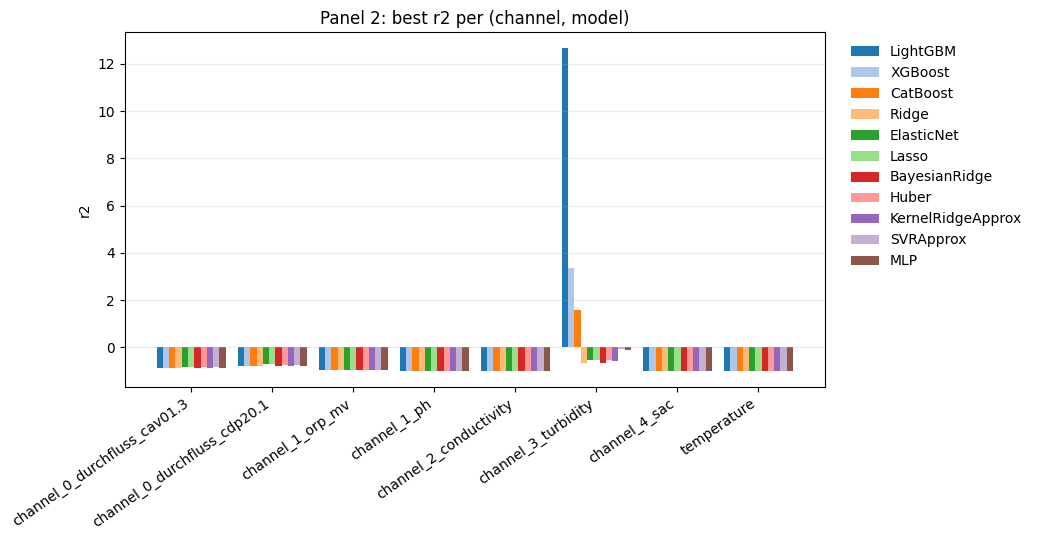

In [20]:
def plot_per_channel_bars(pivot_df: pd.DataFrame, metric: str) -> None:
    if pivot_df.empty:
        print("No results to plot.")
        return

    channels = list(pivot_df.index)
    models = list(pivot_df.columns)
    x = np.arange(len(channels))
    total_width = 0.85
    bar_width = total_width / max(1, len(models))

    fig, ax = plt.subplots(figsize=(max(10, 1.3 * len(channels)), 5.5))
    cmap = plt.get_cmap("tab20")
    for i, model in enumerate(models):
        offsets = x - total_width / 2 + i * bar_width + bar_width / 2
        ax.bar(
            offsets,
            pivot_df[model].values,
            width=bar_width,
            label=model,
            color=cmap(i % cmap.N),
        )

    ax.set_xticks(x)
    ax.set_xticklabels(channels, rotation=35, ha="right")
    ax.set_ylabel(metric)
    panels_label = PANEL_ID if PANEL_ID is not None else ",".join(results)
    ax.set_title(f"Panel {panels_label}: best {metric} per (channel, model)")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(bbox_to_anchor=(1.02, 1.0), loc="upper left", frameon=False)
    fig.tight_layout()
    plt.show()


plot_per_channel_bars(pivot, METRIC)

## 8. Heatmap — channel × model (row-z-scored)

Each row is z-scored across models so a channel whose errors are naturally large (e.g. pH with high volatility) doesn't visually dominate. Green = best model for that channel, red = worst.

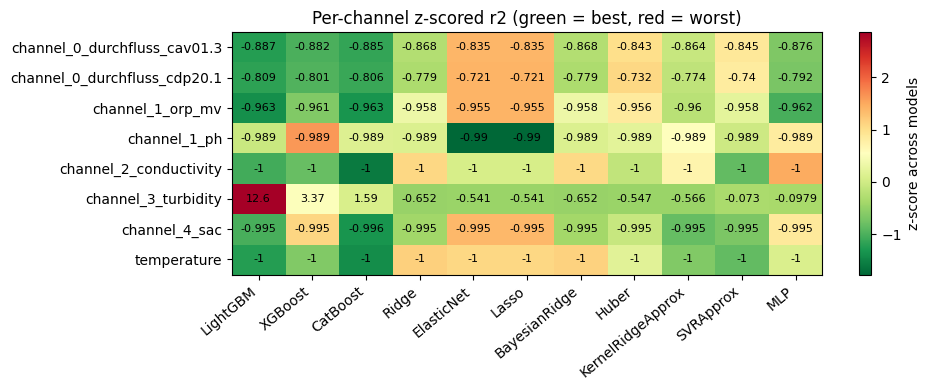

In [21]:
def plot_heatmap(pivot_df: pd.DataFrame, metric: str) -> None:
    if pivot_df.empty:
        print("No results to plot.")
        return

    row_mean = pivot_df.mean(axis=1)
    row_std = pivot_df.std(axis=1).replace(0, np.nan)
    z = pivot_df.sub(row_mean, axis=0).div(row_std, axis=0)

    fig, ax = plt.subplots(
        figsize=(
            max(7, 0.9 * len(pivot_df.columns)),
            max(4, 0.4 * len(pivot_df.index)),
        )
    )
    im = ax.imshow(z.values, aspect="auto", cmap="RdYlGn_r")
    ax.set_xticks(range(len(pivot_df.columns)))
    ax.set_xticklabels(pivot_df.columns, rotation=40, ha="right")
    ax.set_yticks(range(len(pivot_df.index)))
    ax.set_yticklabels(pivot_df.index)
    ax.set_title(f"Per-channel z-scored {metric} (green = best, red = worst)")
    for i in range(pivot_df.shape[0]):
        for j in range(pivot_df.shape[1]):
            val = pivot_df.values[i, j]
            if pd.notna(val):
                ax.text(j, i, f"{val:.3g}", ha="center", va="center", fontsize=8)
    fig.colorbar(im, ax=ax, label="z-score across models")
    fig.tight_layout()
    plt.show()


plot_heatmap(pivot, METRIC)

## 9. Winner distribution

In [22]:
winner_counts = winners.value_counts().rename("channels_won").to_frame()
winner_counts["share"] = winner_counts["channels_won"] / winner_counts["channels_won"].sum()
winner_counts

,channels_won,share
winner,,
LightGBM,3,0.375
CatBoost,3,0.375
ElasticNet,1,0.125
BayesianRidge,1,0.125


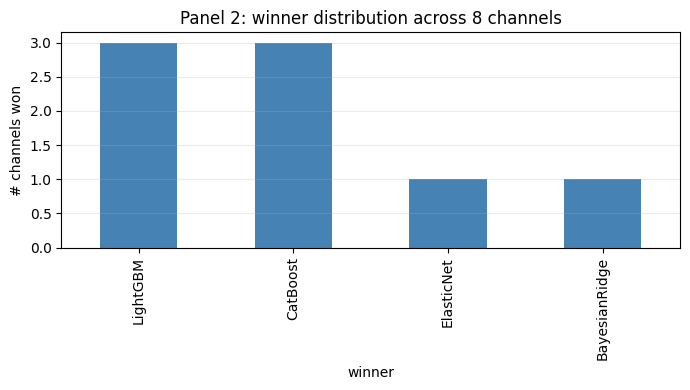

In [23]:
fig, ax = plt.subplots(figsize=(7, 4))
winner_counts["channels_won"].plot.bar(ax=ax, color="steelblue")
ax.set_ylabel("# channels won")
panels_label = PANEL_ID if PANEL_ID is not None else ",".join(results)
ax.set_title(f"Panel {panels_label}: winner distribution across {len(pivot)} channels")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()

## 10. Save the comparison to CSV

Two files land under `data/results/tuning/`:

- `*_model_comparison.csv` — long format: one row per (panel, channel, model)
- `*_model_comparison_pivot.csv` — leaderboard pivot + winner columns

Note: the `Pipeline.tune()` call also wrote its own per-panel YAML under `data/tuning_results/<timestamp>/panel_<id>.yaml` — those carry the full `model_scores` payload for any future automation that wants to read them back.

In [24]:
output_dir = REPO_ROOT / "data" / "results" / "tuning"
output_dir.mkdir(parents=True, exist_ok=True)

panels_label = PANEL_ID if PANEL_ID is not None else "all"
long_path = output_dir / f"panel_{panels_label}_model_comparison.csv"
pivot_path = output_dir / f"panel_{panels_label}_model_comparison_pivot.csv"

long_df.to_csv(long_path, index=False)
leaderboard.to_csv(pivot_path)
print(f"Wrote {long_path}")
print(f"Wrote {pivot_path}")

Wrote /Users/alexprediger/Desktop/Repos/spotanomaly2/data/results/tuning/panel_2_model_comparison.csv
Wrote /Users/alexprediger/Desktop/Repos/spotanomaly2/data/results/tuning/panel_2_model_comparison_pivot.csv
